In [ ]:
import sys, os
from IPython.display import display, HTML, clear_output
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from cycler import cycler
from matplotlib.ticker import ScalarFormatter
from scipy.stats import bootstrap

from pathlib import Path
sys.path.append(str(Path.cwd().parents[1]))
from im_net import datamanager, plotting
import datareader

plot_path = "./figures/Figure3"
plt.rcParams['figure.figsize'] = (2.2, 1.5)
plt.rcParams['figure.dpi'] = 300
plt.rcParams.update({'font.size': 8})

pid_palette = ['#ea535a', '#0066ac', '#9a26c8', '#eebbee', '#cadce0']
paper_palette = ['#1a1a1aff', 'lightgray', '#3ba3ecff', 'darkkhaki', '#ff40ffff', '#c93b9b']
mi_palette = ['#d93a3eff', '#0038a8b3', '#025041ff', '#aaaaaa']
pid_cycler = cycler(color=pid_palette)
performance_palette = sns.color_palette('husl')
sns.set_palette(performance_palette)

# Critical memory loads
alpha_h = 0.14
alpha_red = 1.59
alpha_mi = 1.62

%load_ext autoreload
%autoreload 2

# Figure 3: Classical Goal Functions

This figure compares infomorphic learning using classical goal functions:
- Co-Information: $\Pi_{\mathrm{red}} + \Pi_{\mathrm{syn}}$
- External Mutual Information: $\Pi_{\mathrm{unq,R}} + \Pi_{\mathrm{red}}$

## Panel B: Performance of Classical Goals

Recall accuracy of networks trained with different classical goal functions.

**Training command:**
```bash
python src/training.py +mods/capacity=paper \
    goal=redundancy,coinfo,mi_r params.epochs=5000 \
    params.pref_gpu=False params.seed='range(20)' storage=cluster
```

In [ ]:
# Goal indices in the loaded data
COINFO, REDUNDANCY, MUTUAL_EXT = 0, 1, 2

# TODO: set path to the classical goals experiment folder
file_name = ''
dm_classical, x_alpha, acc_classical, label = datareader.load_capacity_runs(
    file_name, parameter='model.layer1.gamma'
)

n_reps = len(set(dm_classical.sel['params.seed']))
acc_classical = acc_classical.reshape((-1, n_reps, acc_classical.shape[-1]))
acc_all = acc_classical[[REDUNDANCY, MUTUAL_EXT, COINFO]]
print(f"Loaded {dm_classical.all.shape[0]} runs ({n_reps} seeds, {acc_all.shape[-1]} alpha values).")

Loaded 60 runs (20 seeds, 41 alpha values).


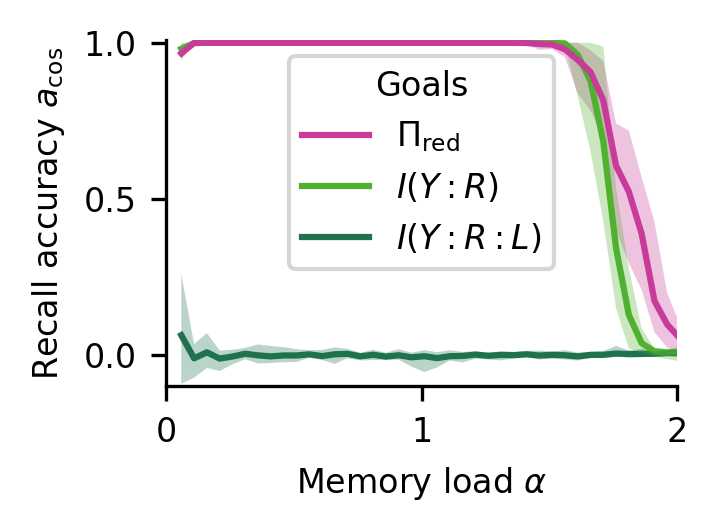

In [3]:
labels = [r'$\Pi_\mathrm{red}$', r'$I(Y : R)$', r'$I(Y : R : L)$']

fig, ax = plt.subplots(1)
ax.set_prop_cycle(color=paper_palette[5:6] + ['#50b131ff', '#1f724fff'])
ax.set_xlabel(r'Memory load $\alpha$')
ax.set_ylabel(r'Recall accuracy $a_{\mathrm{cos}}$')

for i, (x, rule, l) in enumerate(zip(x_alpha, acc_all, labels)):
    plotting.plot_mean_and_area(ax, x[1:], rule[:, 1:], mean_ax=0, label=l, quantile=0.9, median=False, zorder=[2,1,0][i])

plotting.layout_performance(ax, (0, 2), x_log=False, show_legend=True, border_y=(0.1, 0.01))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.legend(title='Goals')
for loc, spine in ax.spines.items():
    if loc in ['right', 'top']:
        spine.set_color('none')
# fig.savefig(f"{plot_path}/classical_capacity.svg", bbox_inches='tight')

## Panel C: PID analysis of mutual information goal

PID decomposition of networks trained with the external mutual information goal $G = I(Y:R)$,
showing how redundancy and uniqueness evolve with memory load beyond the infomorphic capacity $\alpha_c$.

**Training command:**
```bash
python src/training.py params.seed='range(20)' params.epochs=5000 \
    goal=mi_r params.alpha='range(0.01,2.02,0.05)' \
    storage.final.pid=True
```

In [ ]:
# TODO: set path to the MI goal PID experiment folder
pid_path = ''
dm_d = datamanager.DataManager(pid_path, mode='analysis', add_run_properties=True, verbose=0)
datareader.sort_dm(dm_d, 'params.alpha')

n_reps = len(set(dm_d.sel['params.seed']))
n_neurons = dm_d.sel['params.neurons'].iloc[0]
x_alpha = dm_d.sel['params.alpha'][::n_reps]

mean_pid = datareader.pid_to_numpy(dm_d, mean=True).reshape(5, -1, n_reps)
mi_r = mean_pid[datareader.EXTERNAL] + mean_pid[datareader.REDUNDANCY]
redundancy = mean_pid[datareader.REDUNDANCY]
unq_t = mean_pid[datareader.EXTERNAL]
print(f"Loaded {dm_d.all.shape[0]} runs ({n_reps} seeds, {len(x_alpha)} alpha values).")

Loaded 820 runs (20 seeds, 41 alpha values).


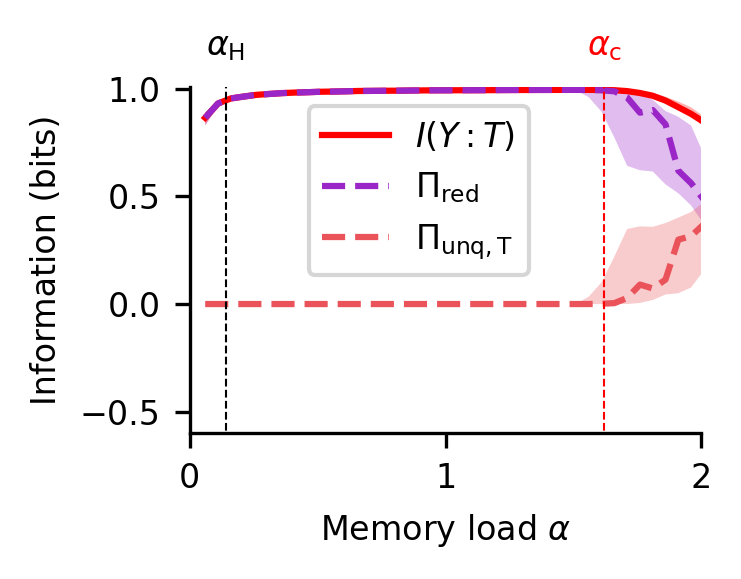

In [5]:
fig, ax = plt.subplots(1)
ax.set_prop_cycle(color=['#ff0000'] + pid_palette[2:3] + pid_palette[0:1])
ax.set_xlabel(r'Memory load $\alpha$')
ax.set_ylabel(r'Information (bits)')

plotting.plot_mean_and_area(ax, x_alpha[1:], mi_r[1:], mean_ax=1, quantile=0.9,
                            label=r'$I(Y:T)$', median=True)
plotting.plot_mean_and_area(ax, x_alpha[1:], redundancy[1:], mean_ax=1, quantile=0.9,
                            label=r'$\Pi_{\mathrm{red}}$', median=True, linestyle='--')
plotting.plot_mean_and_area(ax, x_alpha[1:], unq_t[1:], mean_ax=1, quantile=0.9,
                            label=r'$\Pi_{\mathrm{unq,T}}$', median=True, linestyle='--')

ax.vlines(alpha_h, -1, 2, 'k', '--', linewidth=0.5)
ax.vlines(alpha_mi, -1, 2, '#ff0000', '--', linewidth=0.5)
ax.text(alpha_h, 1 + 0.12, r'$\alpha_\mathrm{H}$',
        horizontalalignment='center', verticalalignment='bottom')
ax.text(alpha_mi, 1 + 0.12, r'$\alpha_{\mathrm{c}}$',
        horizontalalignment='center', verticalalignment='bottom', c='#ff0000')
for loc, spine in ax.spines.items():
    if loc in ['right', 'top']:
        spine.set_color('none')
ax.legend(loc='center left', bbox_to_anchor=(0.2, 0.7))
plotting.layout_performance(ax, y_lim=(-0.5, 1), x_lim=(0, 2), y_ticks=4,
                            x_log=False, show_legend=False, border_y=(0.1, 0.01))
# fig.savefig(f"{plot_path}/info_profile_median.svg", bbox_inches='tight')

## Panel D: Ablation — Uniqueness weight in goal function

Memory capacity as a function of the uniqueness weight $\gamma_{\mathrm{unq,T}}$ in the mixed goal
$G = \gamma_{\mathrm{unq,T}} \Pi_{\mathrm{unq,T}} + \Pi_{\mathrm{red}}$.
The dashed vertical line marks $\gamma_{\mathrm{unq,T}} = 0$ (pure redundancy goal).

**Training command:**
```bash
python src/training.py -m goal=redundancy_and_x \
    pi_x='range(-1,1.1,0.1)' +mods/capacity=optimize \
    params.seed=0,1 params.epochs=5000
```

In [ ]:
# TODO: set path to the ablation experiment folder
path = ''
dm_hard, x_alpha_abl, acc2, label_abl = datareader.load_capacity_runs(path, 'pi_x')

n_reps = len(set(dm_hard.sel['params.seed']))
capacity = np.array(dm_hard.sel['m_max'] / 100).reshape(-1, n_reps)
label_abl = np.array(label_abl).reshape(-1, n_reps)[:, 0]
print(f"Loaded {dm_hard.all.shape[0]} ablation runs ({n_reps} seeds, {len(label_abl)} gamma values).")

Loaded 420 ablation runs (20 seeds, 21 gamma values).


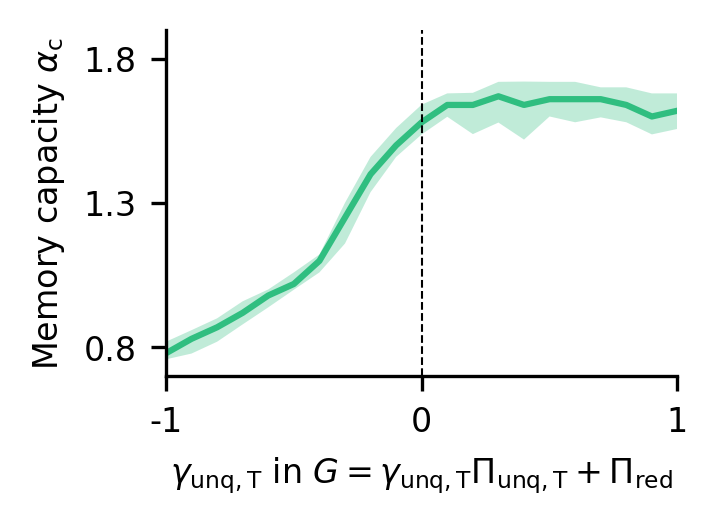

In [7]:
fig, ax = plt.subplots(1)
ax.set_prop_cycle(color='#30be80ff')
ax.set_xlabel(r'$\gamma_\mathrm{unq,T}$ in $G= \gamma_\mathrm{unq,T} \Pi_{\mathrm{unq,T}} + \Pi_{\mathrm{red}}$')
ax.set_ylabel(r'Memory capacity $\alpha_\mathrm{c}$')

plotting.plot_mean_and_area(ax, label_abl, capacity, mean_ax=1, quantile=0.9, median=True)
ax.axvline(color='k', lw=0.5, linestyle='--')
plotting.layout_performance(ax, x_lim=(-1, 1), y_lim=(0.8, 1.8), x_log=False, show_legend=False)
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.set_xticklabels([f'{val}' for val in [-1, 0, 1]], usetex=False)
ax.set_yticklabels([f'{val}' for val in [0.8, 1.3, 1.8]], usetex=False)
for loc, spine in ax.spines.items():
    if loc in ['right', 'top']:
        spine.set_color('none')
# fig.savefig(f"{plot_path}/unique_mixture.svg", bbox_inches='tight')